In [17]:
import zipfile
zip_path = r"train_data (21).zip"
output = r"train"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output)

In [18]:
def extract(zip_path, output):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output)

In [19]:
zip_path = r"test_data (14).zip"
output = r"test"
extract(zip_path, output)

In [20]:
zip_path = r"custom_archive (29).zip"
output = r"model"
extract(zip_path, output)

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18

In [22]:
train_img_dir = "train/images"
train_mask_dir = "train/masks"
test_img_dir = "test/images"

all_files = sorted(os.listdir(train_img_dir))
test_files = sorted(os.listdir(test_img_dir))
print(f"Train+Val: {len(all_files)}, Test: {len(test_files)}")

Train+Val: 230, Test: 50


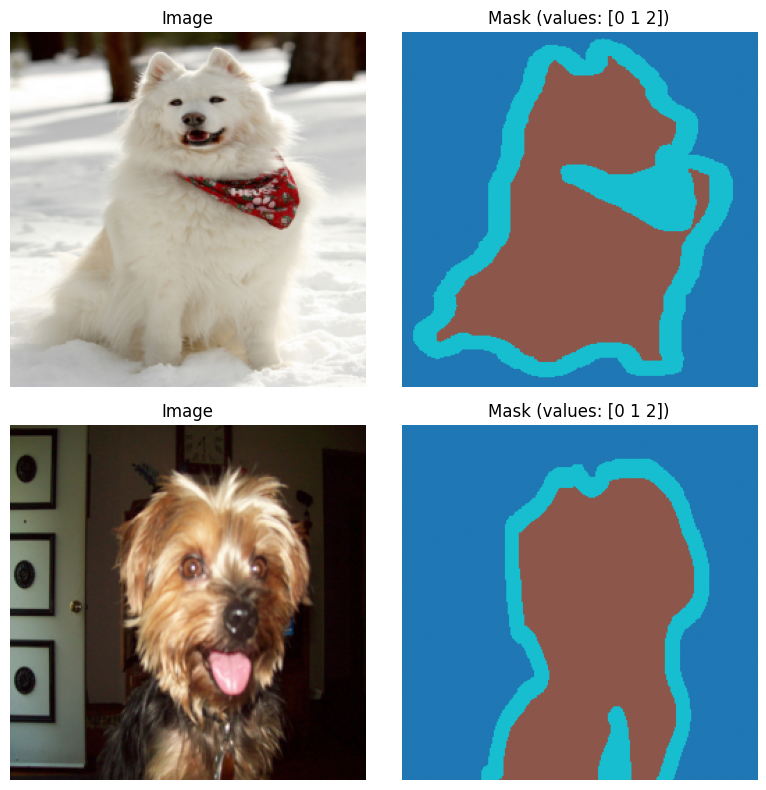

In [23]:
# Visualize 2 examples
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for i in range(2):
    img = np.array(Image.open(os.path.join(train_img_dir, all_files[i])))
    mask = np.array(Image.open(os.path.join(train_mask_dir, all_files[i])))
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(mask, cmap="tab10", vmin=0, vmax=2)
    axes[i, 1].set_title(f"Mask (values: {np.unique(mask)})")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

In [24]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, file_list=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = file_list if file_list else sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = np.array(Image.open(os.path.join(self.img_dir, fname)).convert("RGB"))
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img = (img - MEAN) / STD

        if self.mask_dir:
            mask = np.array(Image.open(os.path.join(self.mask_dir, fname)))
        else:
            mask = np.zeros((256, 256), dtype=np.int64)
        mask = torch.from_numpy(mask).long()
        return img, mask


In [39]:
device = torch.device('cuda:0')
model = resnet18().to(device)
model.load_state_dict(torch.load("resnet18.pth"))

C:\Users\rares\AppData\Local\Temp\ipykernel_9620\1725422757.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet18.pth"))


<All keys matched successfully>

In [40]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [41]:
model.layer1

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [42]:
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Sequential(model.conv1, model.bn1, model.relu, model.maxpool)
        self.enc1 = model.layer1
        self.enc2 = model.layer2
        self.enc3 = model.layer3
        self.enc4 = model.layer4
        self.pool = nn.MaxPool2d(2)
        self.final_up = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
        
        self.bottleneck = nn.Sequential(nn.Conv2d(512, 1024, 3, padding=1), nn.ReLU())

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = nn.Sequential(nn.Conv2d(1024, 512, 3, padding=1), nn.ReLU())
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(512, 256, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU())

        self.final = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        x = self.feat(x)
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim = 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim = 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final_up(self.final(d1))

In [43]:
import tqdm as tqdm

In [44]:
import random

device = torch.device("cuda:0")

all_files_shuffled = all_files.copy()
random.seed(42)
random.shuffle(all_files_shuffled)

train_ds = SegDataset("train/images", "train/masks", file_list=all_files_shuffled[:200])
val_ds   = SegDataset("train/images", "train/masks", file_list=all_files_shuffled[200:])
test_ds  = SegDataset("test/images")

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=0)

unet = TinyUNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

NUM_CLASSES = 3

def compute_iou(preds, masks, num_classes=NUM_CLASSES):
    ious = []
    preds = preds.view(-1)
    masks = masks.view(-1)
    for cls in range(num_classes):
        pred_cls  = (preds == cls)
        mask_cls  = (masks == cls)
        inter = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()
        if union == 0:
            continue
        ious.append(inter / union)
    return sum(ious) / len(ious) if ious else 0.0

for epoch in range(30):
    unet.train()
    total_loss = 0
    for images, masks in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/30 train"):
        images, masks = images.to(device), masks.to(device)
        loss = criterion(unet(images), masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    unet.eval()  
    val_loss = 0
    val_iou  = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            logits = unet(images)
            val_loss += criterion(logits, masks).item()
            preds = logits.argmax(1)
            val_iou += compute_iou(preds.cpu(), masks.cpu())
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou  = val_iou  / len(val_loader)
    scheduler.step(avg_val_iou)

    print(f"Epoch {epoch+1}/30 | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val mIoU: {avg_val_iou:.4f}")


Epoch 1/30 train: 100%|████████████████████████████████████████████████████████████████| 25/25 [00:03<00:00,  7.86it/s]


Epoch 1/30 | Train Loss: 0.8330 | Val Loss: 0.6363 | Val mIoU: 0.4170


Epoch 2/30 train: 100%|████████████████████████████████████████████████████████████████| 25/25 [00:02<00:00,  9.23it/s]


Epoch 2/30 | Train Loss: 0.5348 | Val Loss: 0.5444 | Val mIoU: 0.5348


Epoch 3/30 train: 100%|████████████████████████████████████████████████████████████████| 25/25 [00:02<00:00,  9.67it/s]


...

Epoch 28/30 | Train Loss: 0.1048 | Val Loss: 0.4535 | Val mIoU: 0.7100


Epoch 29/30 train: 100%|███████████████████████████████████████████████████████████████| 25/25 [00:03<00:00,  6.26it/s]


Epoch 29/30 | Train Loss: 0.1044 | Val Loss: 0.4409 | Val mIoU: 0.7127


Epoch 30/30 train: 100%|███████████████████████████████████████████████████████████████| 25/25 [00:04<00:00,  5.96it/s]


Epoch 30/30 | Train Loss: 0.1049 | Val Loss: 0.4452 | Val mIoU: 0.7118


In [45]:
for img in test_loader:
    print(img)
    break

[tensor([[[[-1.5699, -1.5699, -1.5870,  ...,  0.8618,  0.7248,  0.6392],
          [-1.5870, -1.5699, -1.5870,  ...,  0.9132,  0.8104,  0.7248],
          [-1.5699, -1.5699, -1.5699,  ...,  0.9132,  0.8447,  0.7591],
          ...,
          [-1.8268, -1.8268, -1.8268,  ..., -2.0665, -2.0665, -2.0152],
          [-1.8097, -1.8268, -1.8097,  ..., -2.0665, -2.0494, -1.9638],
          [-1.7925, -1.8268, -1.8268,  ..., -2.0665, -2.0152, -1.8782]],

         [[-1.4405, -1.4230, -1.4230,  ...,  1.0805,  0.9755,  0.9230],
          [-1.4580, -1.4055, -1.4055,  ...,  1.1331,  1.0455,  0.9930],
          [-1.4230, -1.4055, -1.3880,  ...,  1.1331,  1.0630,  0.9755],
          ...,
          [-1.6506, -1.6856, -1.7031,  ..., -1.9657, -1.9482, -1.9132],
          [-1.6681, -1.7031, -1.7031,  ..., -1.9832, -1.9482, -1.8782],
          [-1.6506, -1.6856, -1.6856,  ..., -1.9832, -1.9657, -1.8431]],

         [[-1.1073, -1.0724, -1.0724,  ...,  1.2282,  1.0888,  0.9145],
          [-1.0898, -1.0724, 

In [46]:
unet.eval()
test_preds = []
with torch.no_grad():
    for images, _ in test_loader:
        preds = unet(images.to(device)).argmax(1).cpu().numpy()
        test_preds.append(preds)
test_preds = np.concatenate(test_preds).astype(np.uint8)

rows = []
for i in range(len(test_preds)):
    pixels = " ".join(map(str, test_preds[i].flatten()))
    rows.append({"subtaskID": 1, "datapointID": i, "answer": pixels})

df = pd.DataFrame(rows)
df.to_csv("submission.csv", index=False)
print(f"Saved submission.csv — {len(test_preds)} images")


Saved submission.csv — 50 images


In [48]:
unet.eval()
val_loss_final = 0
val_iou_final  = 0
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        logits = unet(images)
        val_loss_final += criterion(logits, masks).item()
        val_iou_final  += compute_iou(logits.argmax(1).cpu(), masks.cpu())

val_loss_final /= len(val_loader)
val_iou_final  /= len(val_loader)

n_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)

print("=" * 50)
print("TinyUNet-ResNet — Rezultate finale")
print(f"  Val mIoU  : {val_iou_final:.4f}")
print(f"  Val Loss  : {val_loss_final:.4f}")
print(f"  Parametri : {n_params:,}")
print("=" * 50)
print("Copiaza aceste valori in README benchmark!")


TinyUNet-ResNet — Rezultate finale
  Val mIoU  : 0.7118
  Val Loss  : 0.4452
  Parametri : 24,950,403
Copiaza aceste valori in README benchmark!
